# Inspeção visual dos patches 2.5D

**Objetivo:** conferir se os patches extraídos (commit 30c2da0) estão corretos antes de treinar o modelo. É a continuação da checagem anti-vazamento da Sprint 2, agora sobre o artefato novo.

**Entradas**
- `patches/patches_2_5d.npz`: 747 patches, cada um com 3 canais de 64×64 pixels, formato `(747, 3, 64, 64)`.
- `transformacao/manifest_patches.csv`: uma linha por patch, com paciente, split e rótulo. A coluna `idx` diz a posição do patch dentro do `.npz`.

**O que foi feito, em ordem**
1. Carregar os dados e conferir os números esperados
2. Checar vazamento de paciente entre treino, validação e teste
3. Checar a proporção benigno/maligno em cada split
4. Olhar os patches: 40 sorteados e os 12 que tocam a borda do exame (o nódulo está no centro?)
5. Medir a faixa preta e ver se ela pode servir de pista de classe
6. Conferir se os canais 1 e 2 são mesmo coronal e sagital
7. Conferir se o número de patches bate com o número de nódulos elegíveis

O resumo dos resultados está no fim, na seção 8.

**Como ler as figuras:** cada linha é um nódulo e as 3 colunas são os 3 canais, que são 3 cortes do mesmo volume, todos passando pelo centro do nódulo. A cruz vermelha marca o centro (32, 32).

## 1. Carregar os dados e conferir os números esperados

**O que faz:** lê o `.npz` (variável `patches`) e o manifesto (variável `df`). Depois confere com `assert` os valores que a issue definiu. Se algum não bater, o notebook para com erro e o grupo deve ser avisado antes de seguir.

**Esperado:** 747 linhas no manifesto e 747 patches; treino 522, validação 114, teste 111; benigno 387, maligno 360.

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

patches = np.load("../patches/patches_2_5d.npz")["patches"]
df = pd.read_csv("manifest_patches.csv")

print("patches:", patches.shape, patches.dtype)
print("manifesto:", df.shape)
print("colunas:", list(df.columns))
df.head()

patches: (747, 3, 64, 64) float16
manifesto: (747, 7)
colunas: ['idx', 'nodule_id', 'patient_id', 'scan_id', 'split', 'label', 'shape']


,idx,nodule_id,patient_id,scan_id,split,label,shape
0,0,LIDC-IDRI-0069_scan2_cluster002,LIDC-IDRI-0069,2,treino,maligno,3x64x64
1,1,LIDC-IDRI-0001_scan12_cluster000,LIDC-IDRI-0001,12,treino,maligno,3x64x64
2,2,LIDC-IDRI-0003_scan14_cluster001,LIDC-IDRI-0003,14,treino,maligno,3x64x64
3,3,LIDC-IDRI-0003_scan14_cluster002,LIDC-IDRI-0003,14,treino,maligno,3x64x64
4,4,LIDC-IDRI-0003_scan14_cluster003,LIDC-IDRI-0003,14,treino,maligno,3x64x64


Quantos patches há em cada grupo e em cada rótulo:

In [22]:
print("linhas no manifesto:", len(df))
print("patches no .npz:", patches.shape[0])
print(df["split"].value_counts())
print(df["label"].value_counts())

linhas no manifesto: 747
patches no .npz: 747
split
treino       522
validacao    114
teste        111
Name: count, dtype: int64
label
benigno    387
maligno    360
Name: count, dtype: int64


Conferência com os números esperados (se algum estiver errado, dá erro):

In [23]:
assert len(df) == 747
assert patches.shape[0] == 747
assert (df["split"] == "treino").sum() == 522
assert (df["split"] == "validacao").sum() == 114
assert (df["split"] == "teste").sum() == 111
assert (df["label"] == "benigno").sum() == 387
assert (df["label"] == "maligno").sum() == 360
print("Números conferem")

Números conferem


## 2. Checagem anti-vazamento (`patient_id`)

**Por que:** se o mesmo paciente aparece no treino e no teste, o modelo pode reconhecer o paciente em vez de aprender a doença, e a métrica fica melhor do que a realidade. Isso é vazamento de dados.

**O que faz:** monta o conjunto de pacientes de cada split e confere que nenhum paciente aparece em dois splits.

**Cuidado da issue:** a versão antiga usava nomes de split errados (`train/val/test` em vez de `treino/validacao/teste`). Os conjuntos ficavam vazios e a checagem passava sem checar nada. Por isso há `assert len(...) > 0` antes de comparar.

In [24]:
treino = set(df[df["split"] == "treino"]["patient_id"])
validacao = set(df[df["split"] == "validacao"]["patient_id"])
teste = set(df[df["split"] == "teste"]["patient_id"])

assert len(treino) > 0
assert len(validacao) > 0
assert len(teste) > 0

assert len(treino & validacao) == 0
assert len(treino & teste) == 0
assert len(validacao & teste) == 0
print("Nenhum paciente em comum entre os splits")

Nenhum paciente em comum entre os splits


## 3. Proporção benigno/maligno por split

**O que faz:** calcula a porcentagem de benignos e malignos dentro de cada split.

**Por que:** a extração excluiu alguns nódulos. É preciso confirmar que a proporção de classes não ficou desigual entre treino, validação e teste.

In [57]:
proporcoes = df.groupby('split')['label'].value_counts(normalize=True) * 100
print("Proporção de classes (%) por split:\n")
print(proporcoes)

Proporção de classes (%) por split:

split      label  
teste      benigno    52.252252
           maligno    47.747748
treino     benigno    51.724138
           maligno    48.275862
validacao  benigno    51.754386
           maligno    48.245614
Name: proportion, dtype: float64


**Resultado:** é parecida nos três grupos: cerca de 52% benignos e 48% malignos (treino 51,7 e 48,3; validação 51,8 e 48,2; teste 52,3 e 47,7).

## 4. Inspeção visual: o nódulo está no centro?

**Por que é obrigatória:** um patch descentralizado continua parecendo um pedaço de pulmão e passa em qualquer verificação estatística. Olhar é o único jeito de pegar erro de sistema de coordenadas.

### 4.1 Quarenta patches sorteados

**O que faz:** sorteia 40 patches (semente 42, então o sorteio se repete) e mostra os 3 canais de cada um, em grupos de 8. O nódulo deveria estar embaixo da cruz vermelha. A função `mostrar` é reutilizada nas próximas seções.

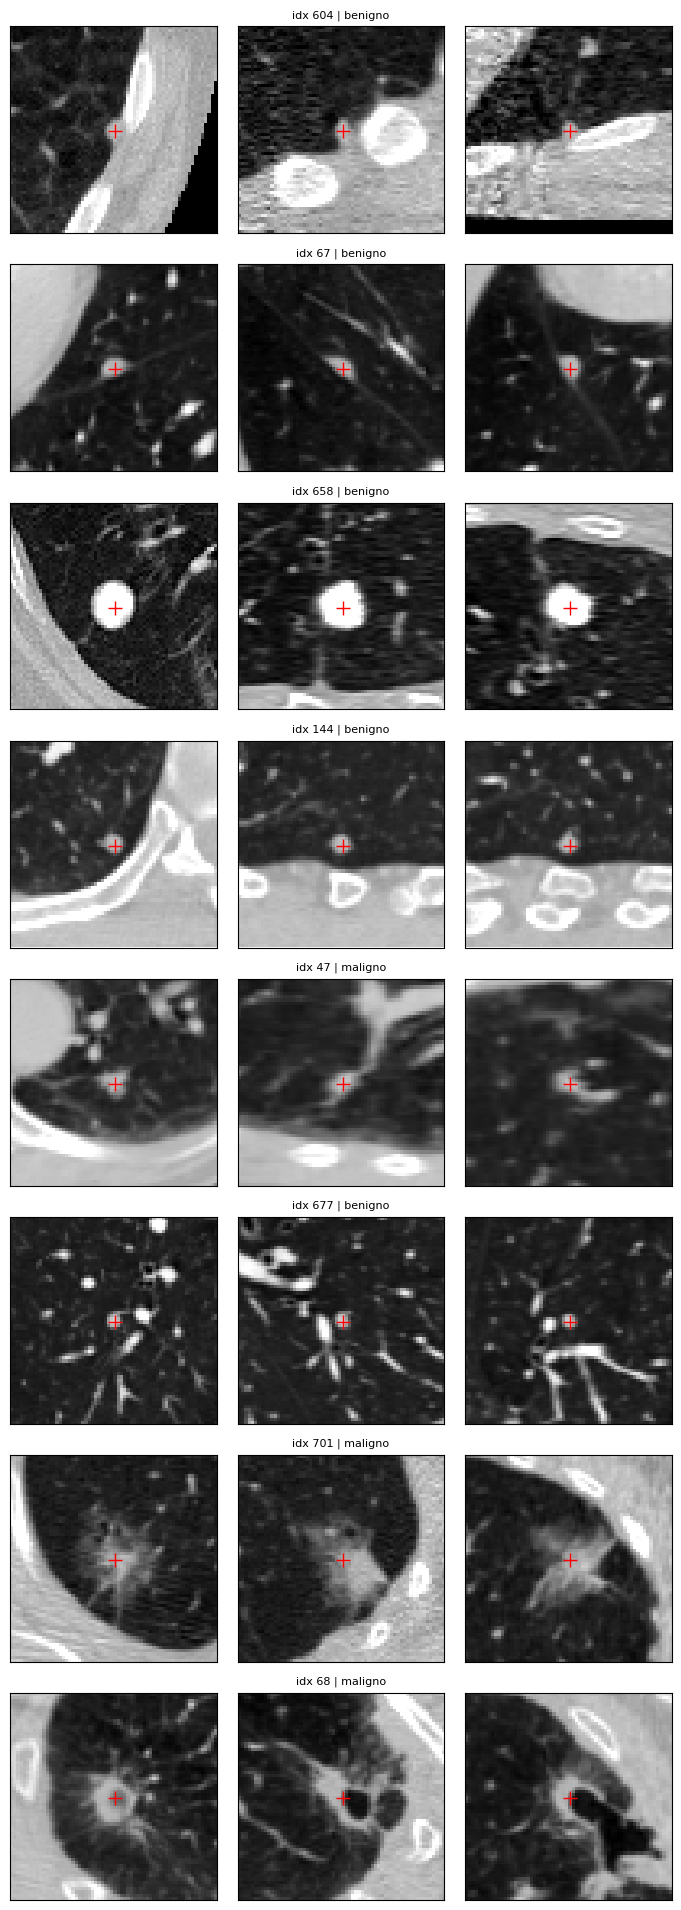

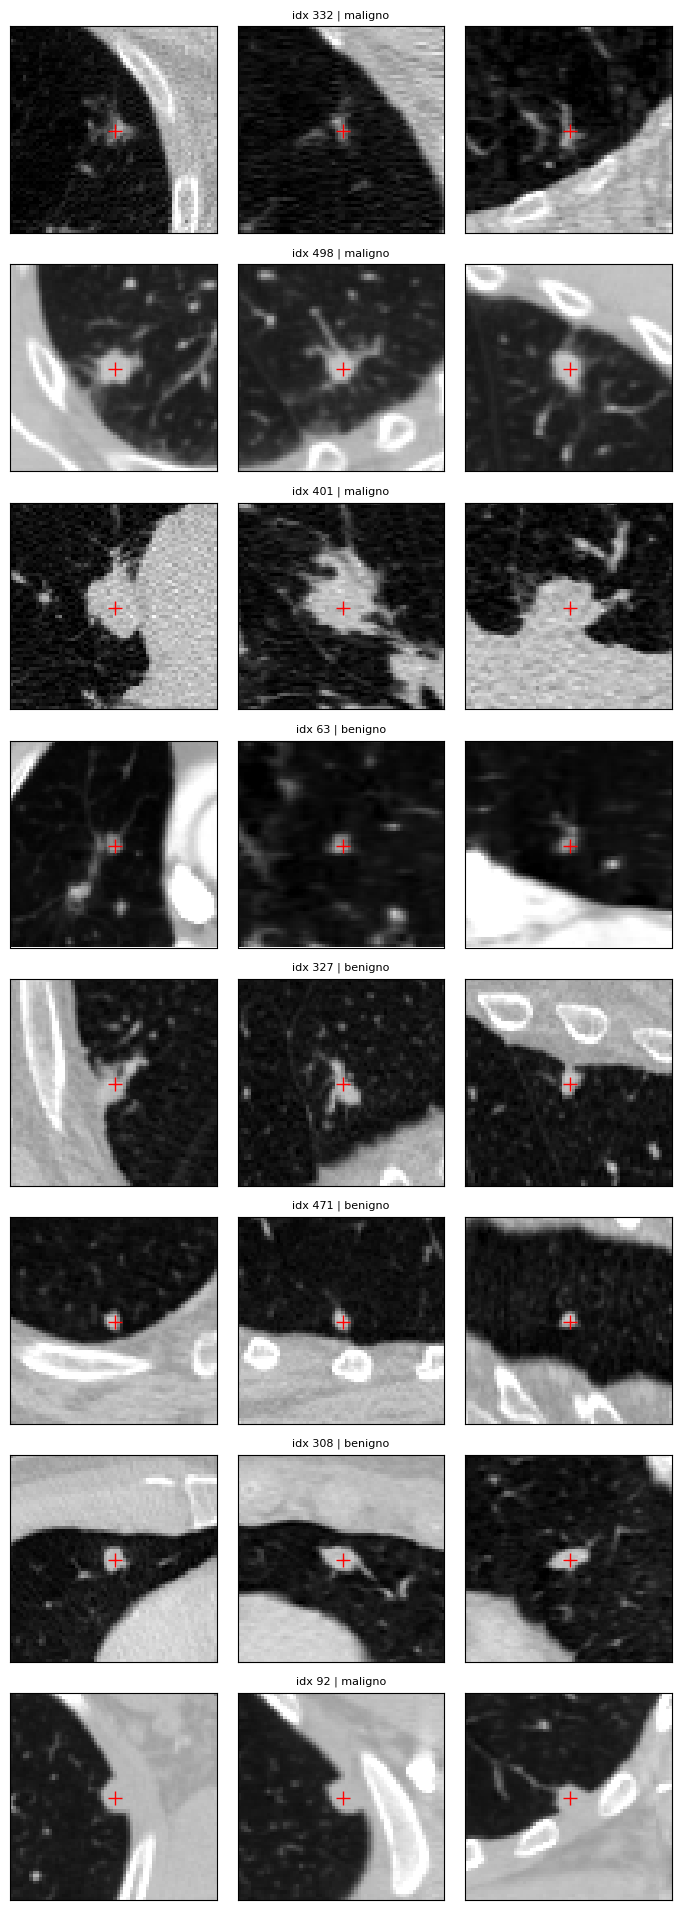

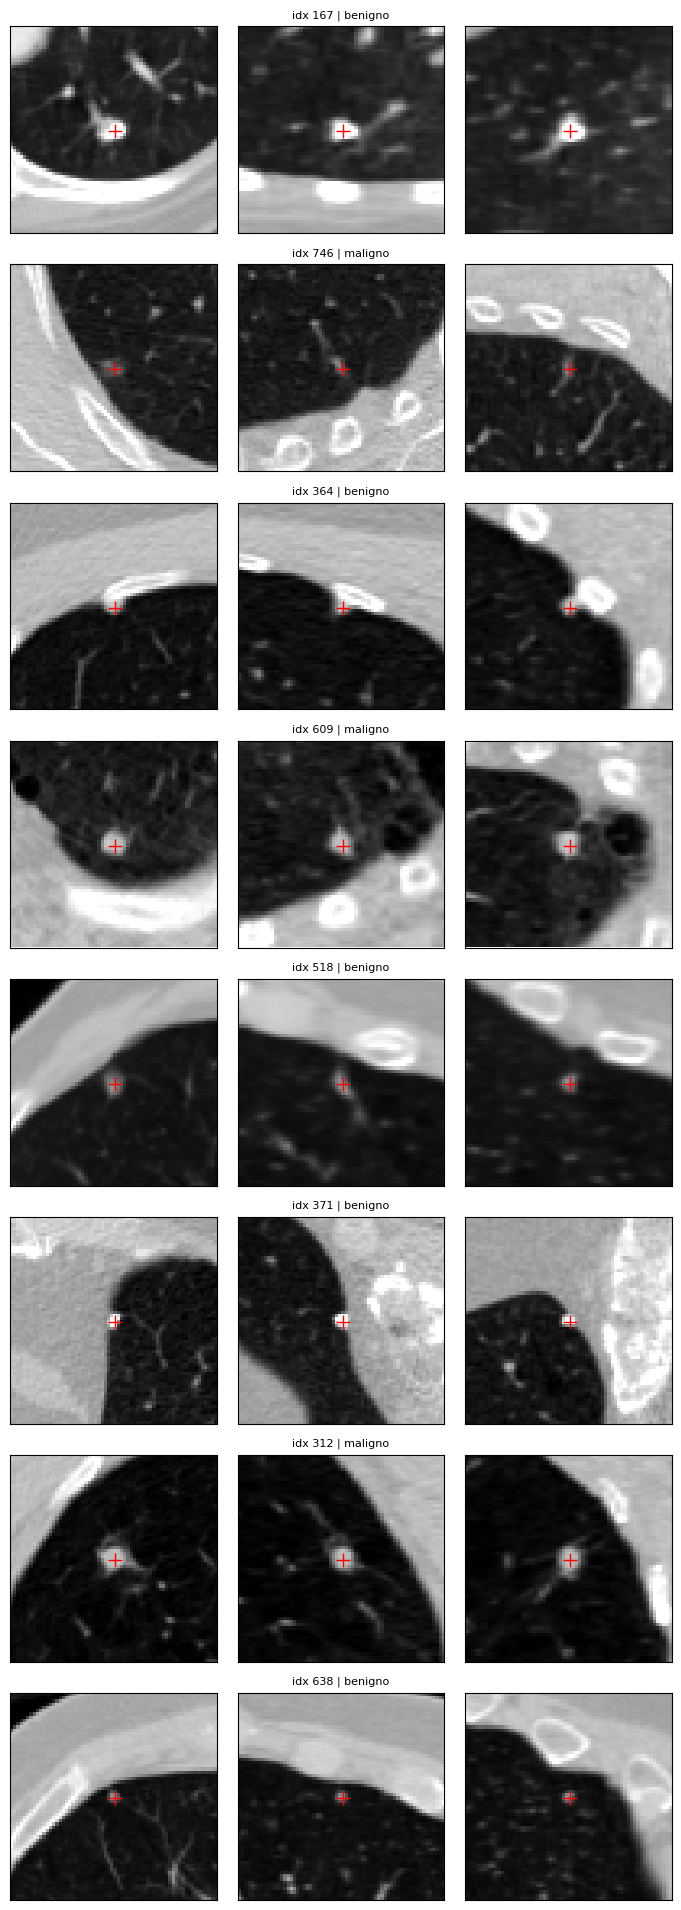

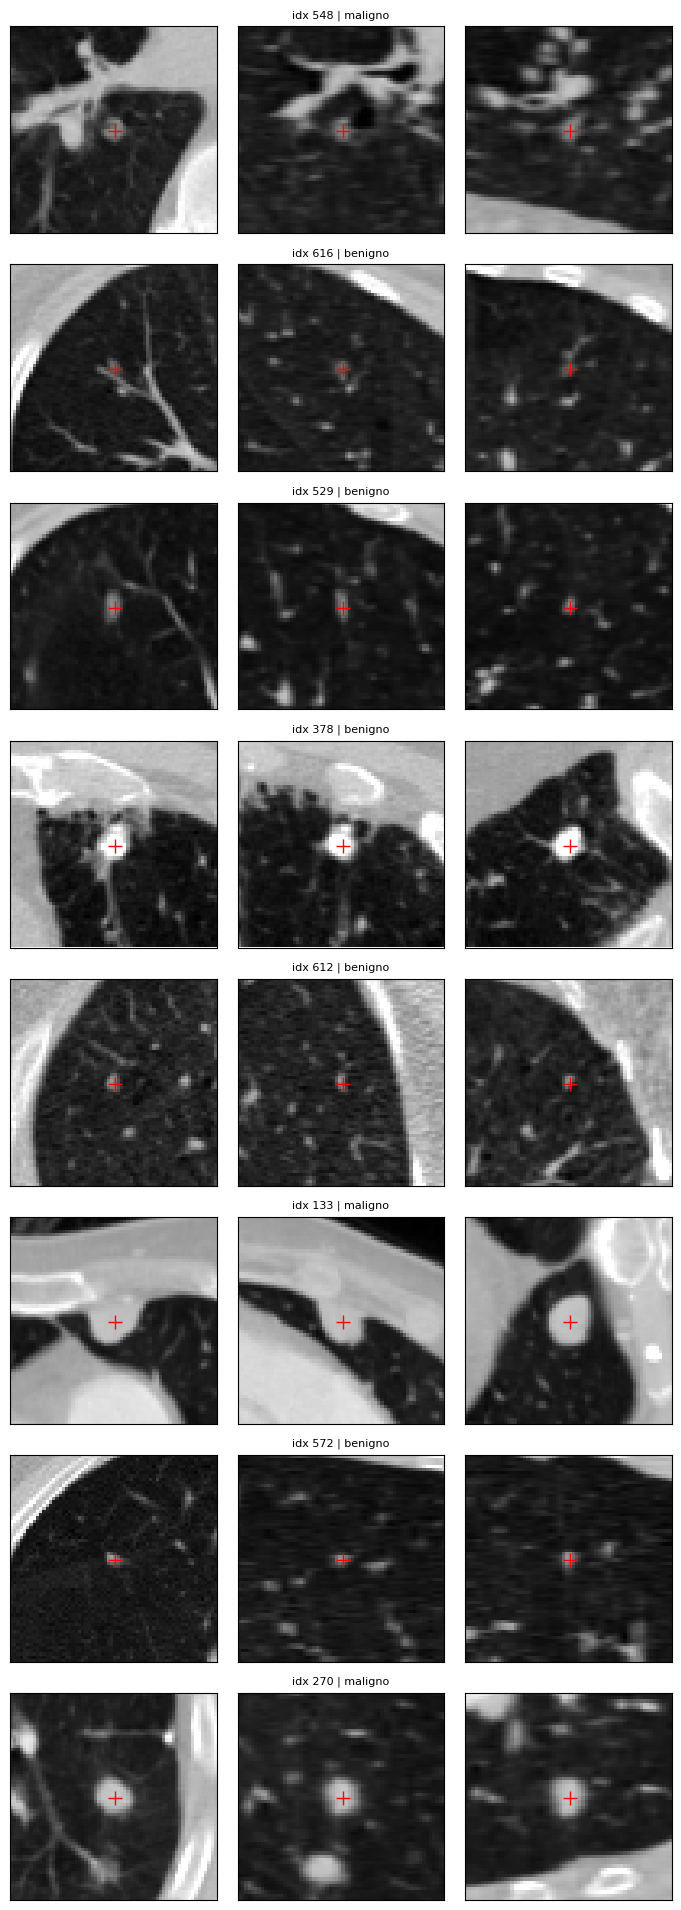

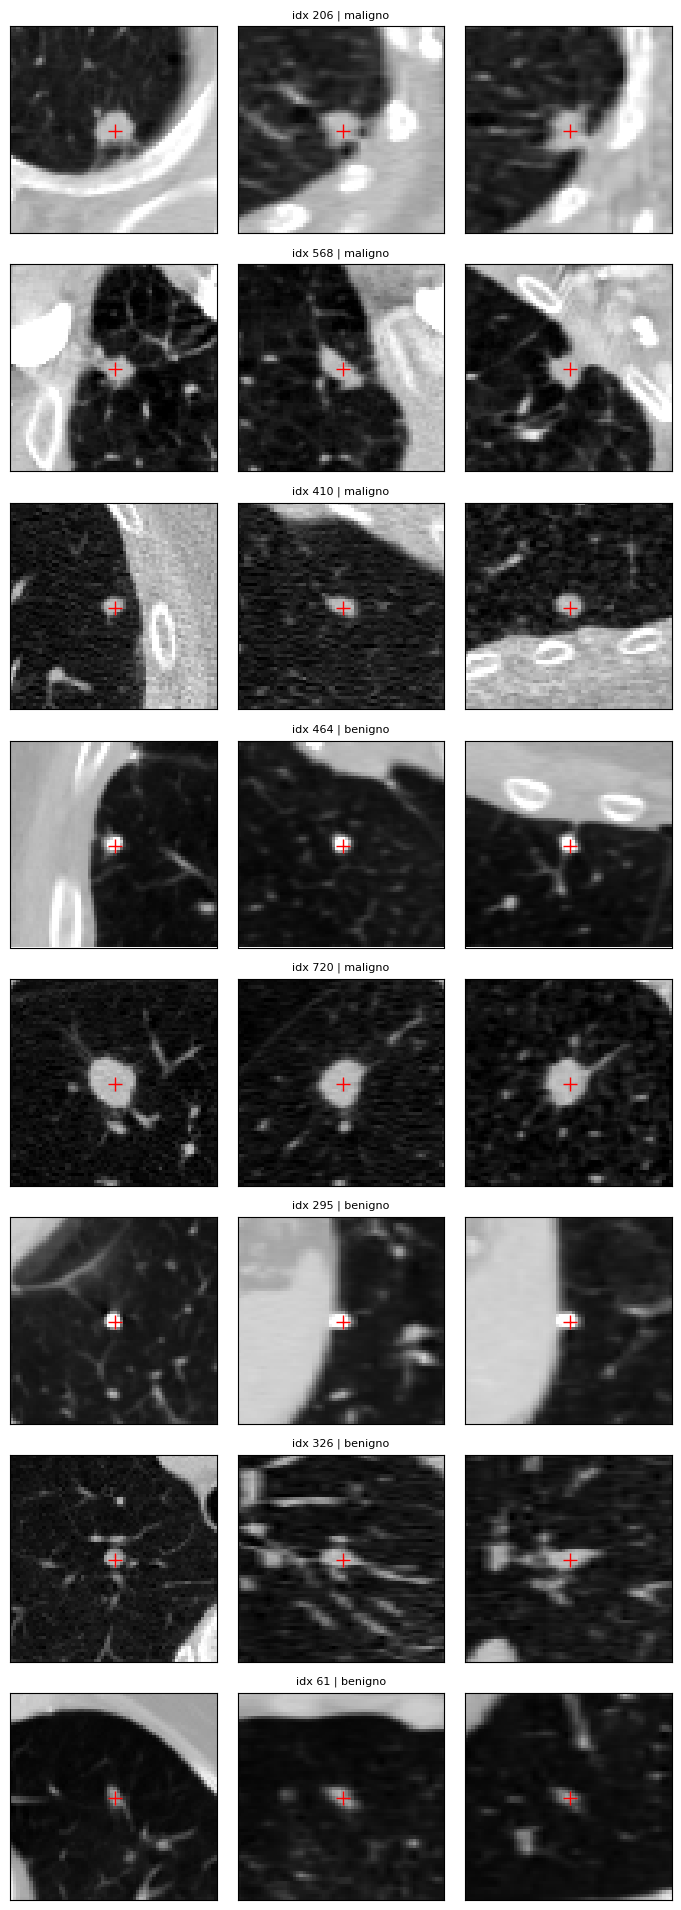

In [58]:
def mostrar(linhas):
    fig, eixos = plt.subplots(len(linhas), 3, figsize=(7, 2.4 * len(linhas)), squeeze=False)
    for r, (_, linha) in enumerate(linhas.iterrows()):
        for c in range(3):
            ax = eixos[r][c]
            ax.imshow(patches[int(linha["idx"]), c], cmap="gray", vmin=0, vmax=1)
            ax.plot(32, 32, "r+", markersize=10)
            ax.set_xticks([])
            ax.set_yticks([])
        eixos[r][1].set_title(f'idx {linha["idx"]} | {linha["label"]}', fontsize=8)
    plt.tight_layout()
    plt.show()

rng = np.random.default_rng(42)
sorteados = df.iloc[rng.choice(len(df), 40, replace=False)]

for k in range(0, 40, 8):
    mostrar(sorteados.iloc[k:k + 8])

**Achados dos 40 patches sorteados:**
- Descentralizados: 0
- Duvidosos: idx 604, 364, 371 (nódulo encostado na parede do tórax), 746, 616, 612 (nódulo não nítido)

### 4.2 Os 12 patches de borda

**O que fiz:** a issue lista 12 patches cujo recorte encosta na borda do exame. Olhei esses à parte, porque são os que têm mais chance de dar problema.

12 patches de borda


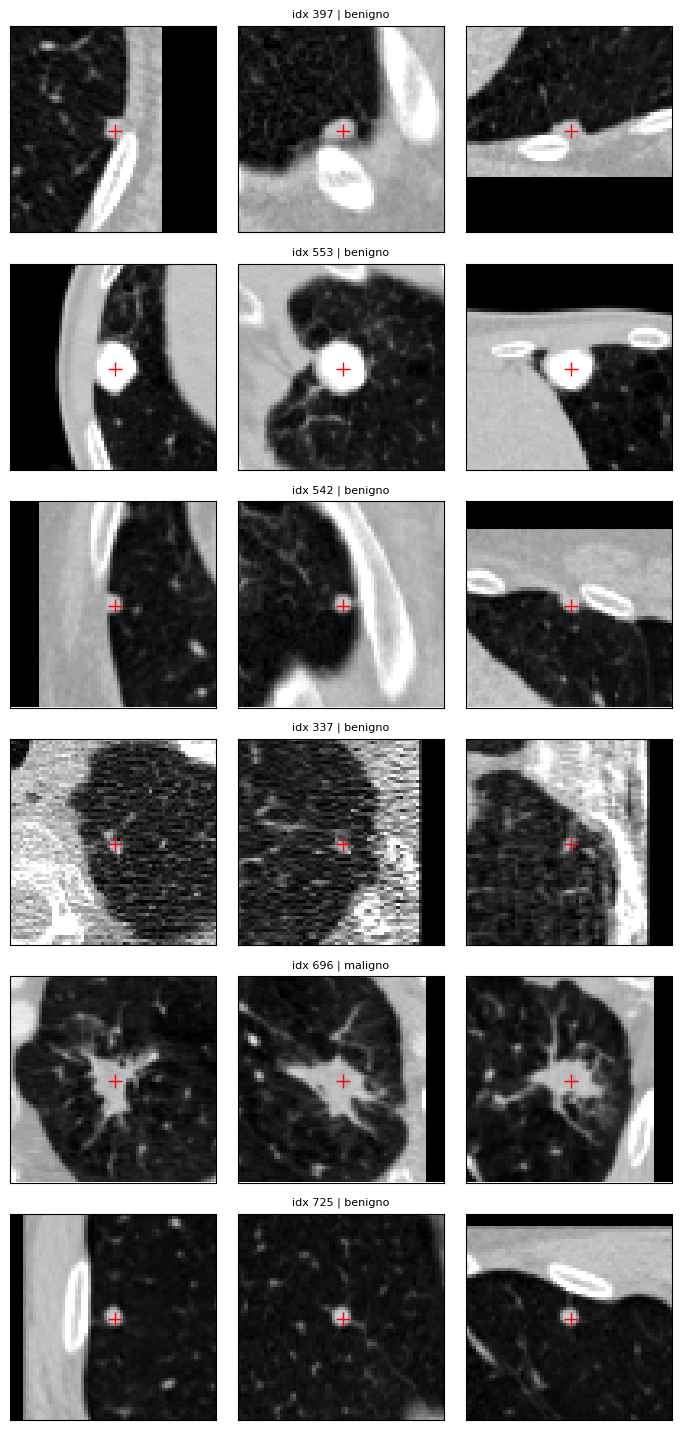

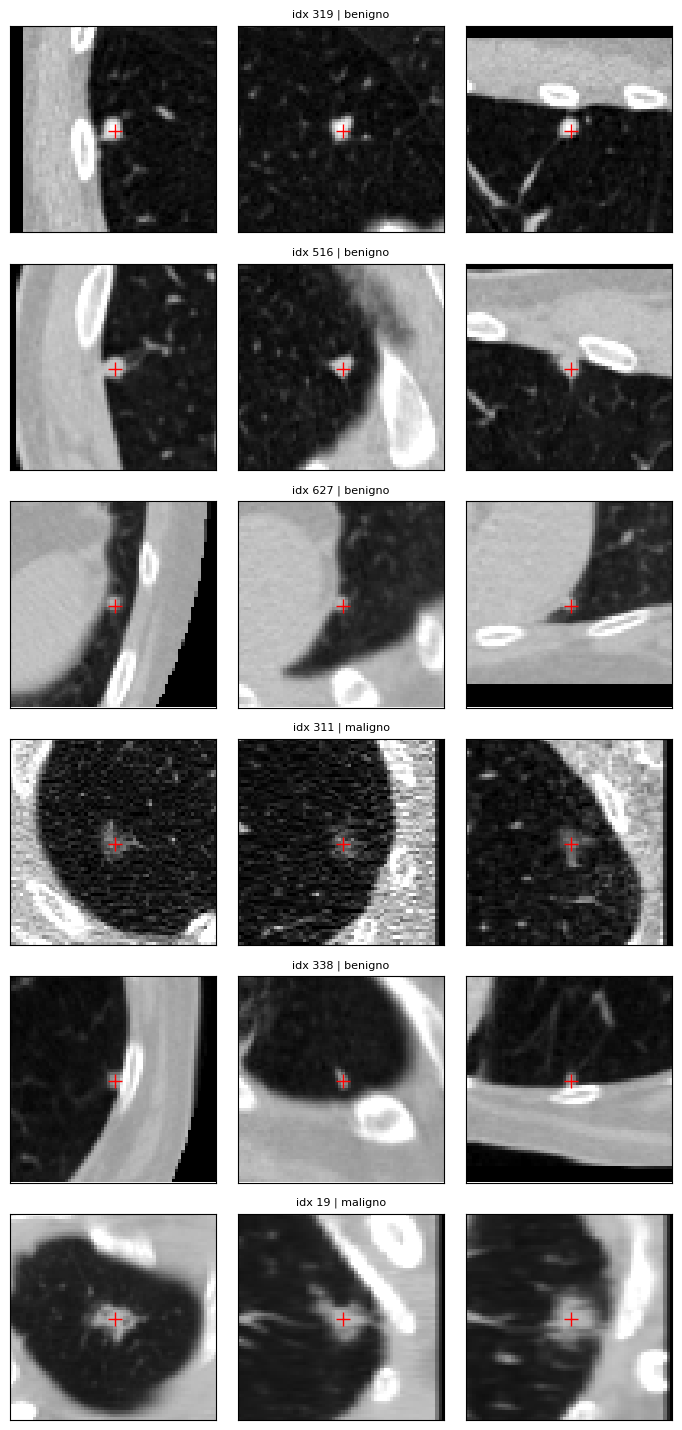

In [43]:
borda_ids = [
    "LIDC-IDRI-0463_scan468_cluster000",	
    "LIDC-IDRI-0951_scan704_cluster000",	
    "LIDC-IDRI-0985_scan670_cluster000",	
    "LIDC-IDRI-0369_scan373_cluster000",	
    "LIDC-IDRI-0715_scan940_cluster000",	
    "LIDC-IDRI-0655_scan1000_cluster001",	
    "LIDC-IDRI-0318_scan319_cluster000",
    "LIDC-IDRI-0637_scan642_cluster001",	
    "LIDC-IDRI-0838_scan817_cluster001",	
    "LIDC-IDRI-0305_scan305_cluster007",
    "LIDC-IDRI-0371_scan375_cluster000",	
    "LIDC-IDRI-0016_scan27_cluster005",
]



borda = df.set_index("nodule_id").loc[borda_ids].reset_index()
print(len(borda), "patches de borda")

mostrar(borda.iloc[:6])
mostrar(borda.iloc[6:])

**Achados dos 12 patches de borda:**
- Descentralizados: 0
- Duvidosos: idx 337 e 311 (imagem ruidosa, nódulo pouco nítido), idx 627 (nódulo fino colado à pleura, ao lado do coração)
- Todos os 12 têm faixa preta em pelo menos um canal (detalhes na seção 5).

## 5. A faixa preta

**O que é:** quando o recorte passa da borda do exame, a parte de fora fica preta. Nos patches de borda dá para ver essa faixa.

**Por que importa:** 9 dos 12 patches de borda são benignos. Se a rede aprender "tem faixa preta, então é benigno", ela estaria usando um atalho em vez de olhar o nódulo.

**O que fiz:** fiz o código procurar faixas pretas em todos os 747 patches (uma linha ou coluna inteira preta na borda da imagem). Depois contei quantos são benignos e quantos malignos, e em que grupo estão.

**O que a saída mostra, em ordem:**
1. uma tabela com a porcentagem preta de cada canal, nos 12 patches de borda;
2. quantos patches têm faixa em todo o conjunto;
3. a contagem por rótulo e por grupo;
4. um número chamado `p`, que responde: a diferença entre benignos e malignos pode ser só acaso? Quanto mais alto o `p` (perto de 0,3 ou mais), mais provável que seja acaso.

In [46]:
zeros = (patches == 0)
frac_zero = zeros.mean(axis=(2, 3))   # (747, 3): fração de pixels == 0 por canal

# faixa reta: alguma borda inteira (linha/coluna extrema) de algum canal está 100% zerada
faixa_reta = (zeros[:, :, 0, :].all(-1) | zeros[:, :, -1, :].all(-1)
              | zeros[:, :, :, 0].all(-1) | zeros[:, :, :, -1].all(-1)).any(axis=1)
df["faixa_reta"] = faixa_reta

tab = df[df["nodule_id"].isin(borda_ids)][["idx", "nodule_id", "split", "label"]].copy()
for c, nome in enumerate(["axial(0)", "canal1", "canal2"]):
    tab[nome + " %zero"] = (100 * frac_zero[tab["idx"].to_numpy(), c]).round(1)
print(tab.to_string(index=False))

na_lista = df["nodule_id"].isin(borda_ids)
print("\nPatches com faixa reta na borda:", faixa_reta.sum())
print("  dos 12 da lista:", (faixa_reta & na_lista).sum(), "| fora da lista:", df.loc[faixa_reta & ~na_lista, "idx"].tolist())
print("\nPor classe (linhas) x faixa:")
print(pd.crosstab(df["label"], df["faixa_reta"]))
print("\nPor split:")
print(pd.crosstab(df["split"], [df["label"], df["faixa_reta"]]))

from scipy.stats import fisher_exact
ben = df["label"] == "benigno"
tabela = [[(faixa_reta & ben).sum(), (~faixa_reta & ben).sum()],
          [(faixa_reta & ~ben).sum(), (~faixa_reta & ~ben).sum()]]
print("\nFisher (faixa x classe): p =", round(fisher_exact(tabela)[1], 3))

 idx                          nodule_id  split   label  axial(0) %zero  canal1 %zero  canal2 %zero
  19   LIDC-IDRI-0016_scan27_cluster005  teste maligno             0.0           1.6           1.6
 311  LIDC-IDRI-0305_scan305_cluster007  teste maligno             1.2           5.3           3.2
 319  LIDC-IDRI-0318_scan319_cluster000  teste benigno             6.4           0.0           6.3
 337  LIDC-IDRI-0369_scan373_cluster000 treino benigno             0.5          11.1          11.0
 338  LIDC-IDRI-0371_scan375_cluster000 treino benigno             8.8           0.0           7.6
 397  LIDC-IDRI-0463_scan468_cluster000  teste benigno            26.7           0.3          26.7
 516  LIDC-IDRI-0637_scan642_cluster001 treino benigno             3.2           0.0           3.1
 542  LIDC-IDRI-0985_scan670_cluster000 treino benigno            14.1           0.3          14.1
 553  LIDC-IDRI-0951_scan704_cluster000 treino benigno            22.7           0.0          21.2
 627  LIDC

**Os 3 patches com faixa que não estavam na lista** (idx 314, 316, 604):

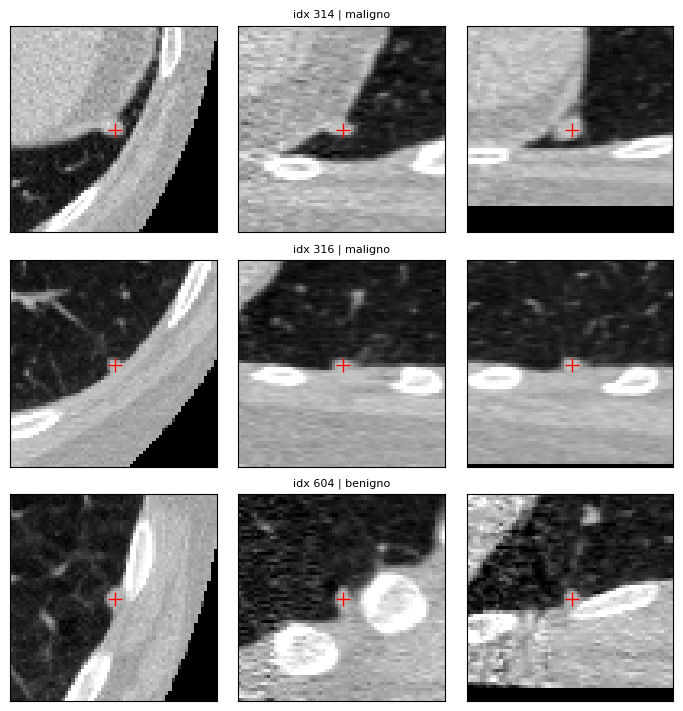

In [45]:
extras = df[faixa_reta & ~na_lista]
mostrar(extras)

**Achados da faixa preta:**
- 15 patches têm faixa: os 12 da lista e mais 3 (idx 314 e 316, malignos; idx 604, benigno). Nos 3 o nódulo está no centro.
- 10 são benignos e 5 são malignos. Parece pender para benigno, mas com tão poucos casos pode ser acaso (`p` ≈ 0,30).
- 11 estão no treino, 4 no teste e nenhum na validação. Então, se a rede usar a faixa como atalho, a validação não vai mostrar isso.
- São só 2% dos patches. Não há prova de que a faixa ajude a rede a adivinhar, mas 15 casos também não bastam para garantir que não ajuda. Precisamos decidir se escondemos a faixa ou tiramos esses 15 patches, ou se deixa como está.

## 6. Canais 1 e 2: estão trocados?

**Contexto:** cada patch tem 3 visões do nódulo, os canais. Segundo o `extrai_patches.py`:
- canal 0 = **axial** (vista de cima)
- canal 1 = **coronal** (vista de frente)
- canal 2 = **sagital** (vista de lado)

**O que quero saber:** se os canais 1 e 2 não estão com os nomes trocados. Fiz dois testes.

**Teste 1: olhar as costelas.** Na vista de frente (coronal), as costelas aparecem como ovais pequenos em fila. Na vista de lado (sagital), aparecem como uma faixa comprida e curva.

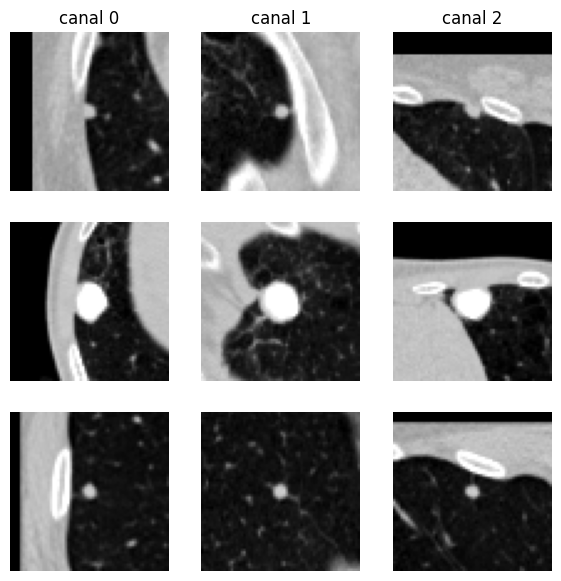

In [48]:
patches = np.load("../patches/patches_2_5d.npz")["patches"]

fig, eixos = plt.subplots(3, 3, figsize=(7, 7))
for linha, idx in enumerate([542, 553, 725]):
    for canal in range(3):
        eixos[linha][canal].imshow(patches[idx, canal], cmap="gray", vmin=0, vmax=1)
        eixos[linha][canal].axis("off")
        if linha == 0:
            eixos[linha][canal].set_title(f"canal {canal}")
plt.show()

**O que foi observado:** os ovais enfileirados aparecem no canal 2, nos 3 nódulos. A faixa comprida aparece no canal 1 só no idx 542. Ou seja, o canal 2 parece coronal e o canal 1 parece sagital, o contrário do script. Isso é só um indício, por isso faço o teste 2.

**Teste 2: espelhar a imagem.** Tirei a média de todos os patches (uma imagem média por canal) e espelhei cada uma no sentido vertical. Depois medi o quanto a imagem mudou. Número baixo = quase não mudou.

Na vista de frente (coronal), a imagem quase não muda ao espelhar, porque o corpo é simétrico e há nódulos nos dois pulmões. Então o canal com o número mais baixo é o coronal.

In [59]:
p = patches.astype(np.float32)

def assimetria(imagem, eixo):
    return np.abs(imagem - np.flip(imagem, axis=eixo)).mean()

for canal in (1, 2):
    medio = p[:, canal].mean(axis=0)   # patch médio dos 747 nódulos
    print(f"canal {canal}: espelhando linhas = {assimetria(medio, 0):.4f}")

canal 1: espelhando linhas = 0.0254
canal 2: espelhando linhas = 0.0064


**Resultado:** canal 1 = 0,0254 (mudou bastante) e canal 2 = 0,0064 (quase não mudou). Então o canal 2 é o coronal.

**Conclusão: os canais 1 e 2 estão com os nomes trocados.** Canal 1 = sagital, canal 2 = coronal.
- Não afeta o treino, porque a ordem dos canais é sempre a mesma.
- Afeta o nome em `extrai_patches.py` e em `docs/criterios_transformacao.md`, e qualquer espelhamento de esquerda para direita usado como augmentation.
- Só foi conferido nos patches, sem os exames originais.
- Sugestão: corrigir os nomes nos dois arquivos, sem refazer a extração.

### Correção da ordem dos canais — Sprint 4

A divergência entre os canais coronal e sagital do arquivo
`patches_2_5d.npz` foi corrigida na Sprint 4.

A ordem definitiva dos canais passou a ser:

- canal 0: axial
- canal 1: coronal
- canal 2: sagital

A correção consistiu apenas na troca dos canais 1 e 2.
O canal axial, a ordem dos 747 patches e os respectivos
`nodule_id` permaneceram inalterados.

## 7. O número de imagens bate com o número de nódulos?

**O que fiz:** contei os nódulos elegíveis usando os arquivos da seleção, sem usar o manifesto: 751 no total, menos 3 excluídos por agrupamento instável e 1 por espaçamento irregular. Depois comparei com o manifesto e com o `.npz`. Também conferi que são os **mesmos** nódulos, e não só a mesma quantidade.

seleção: 751 | excluídos: 3 (agrupamento) + 1 (espaçamento) | elegíveis: 747
manifesto: 747 | patches no .npz: 747 | não extraídos: 0
Contagem, identidade dos nódulos, split, rótulo e paciente conferem


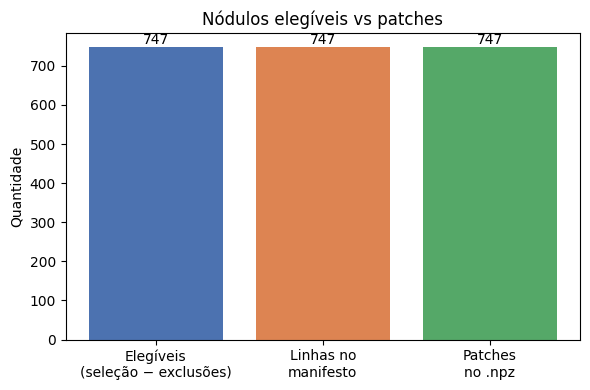

In [60]:
sel = pd.read_csv("../selecao/nodulos_com_split.csv")
ex_agrup = pd.read_csv("../selecao/excluidos_agrupamento_instavel.csv")
ex_espac = pd.read_csv("../selecao/excluidos_espacamento_irregular.csv")
nao_extraidos = pd.read_csv("patches_nao_extraidos.csv")

elegiveis = set(sel["nodule_id"]) - set(ex_agrup["nodule_id"]) - set(ex_espac["nodule_id"])
print(f"seleção: {len(sel)} | excluídos: {len(ex_agrup)} (agrupamento) + {len(ex_espac)} (espaçamento) | elegíveis: {len(elegiveis)}")
print(f"manifesto: {len(df)} | patches no .npz: {patches.shape[0]} | não extraídos: {len(nao_extraidos)}")

assert len(elegiveis) == 747
assert len(df) == len(elegiveis) == patches.shape[0]
assert set(df["nodule_id"]) == elegiveis              # mesmos nódulos, não só a mesma quantidade
assert len(nao_extraidos) == 0
assert (df["idx"].to_numpy() == np.arange(len(df))).all()   # idx = posição no .npz

# split, rótulo e paciente do manifesto == seleção
m = df.merge(sel[["nodule_id", "split", "rotulo_binario", "patient_id"]], on="nodule_id", suffixes=("", "_sel"))
assert (m["split"] == m["split_sel"]).all()
assert (m["label"] == m["rotulo_binario"]).all()
assert (m["patient_id"] == m["patient_id_sel"]).all()
print("Contagem, identidade dos nódulos, split, rótulo e paciente conferem")

fig, ax = plt.subplots(figsize=(6, 4))
nomes = ["Elegíveis\n(seleção − exclusões)", "Linhas no\nmanifesto", "Patches\nno .npz"]
valores = [len(elegiveis), len(df), patches.shape[0]]
barras = ax.bar(nomes, valores, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("Quantidade")
ax.set_title("Nódulos elegíveis vs patches")
ax.bar_label(barras)
plt.tight_layout()
plt.show()

**Resultado:** 751 − 3 − 1 = 747 elegíveis. O manifesto e o `.npz` têm 747 cada, com os mesmos nódulos, e nenhum patch ficou sem extrair.

## 8. Resumo

| Verificação | Resultado |
|---|---|
| Números esperados (747; 522/114/111; 387/360) | batem |
| Paciente em mais de um grupo | nenhum |
| Proporção benigno/maligno por grupo | parecida (cerca de 52% / 48%) |
| Nódulo no centro (40 sorteados + 12 de borda) | 0 descentralizados |
| Faixa preta | 15 patches (12 da lista + 3), 10 benignos e 5 malignos, nenhum na validação |
| Canais 1 e 2 | nomes trocados: canal 1 = sagital, canal 2 = coronal |
| Número de patches = número de nódulos elegíveis | bate (747) |

**Decisões que ficam para o grupo**
- Faixa preta: esconder a faixa ou tirar os 15 patches, ou deixar como está e só registrar.
- Canais: corrigir os nomes em `extrai_patches.py` e `docs/criterios_transformacao.md`.